# 2. Exploratory Data Analysis

## Objective
Perform comprehensive exploratory data analysis on the training data and any external data sources.

### Data Sources:
1. Training data (train.csv)
2. External lexicon data (from data augmentation)
3. Publications data (for potential additional context)

In [1]:
# Parameters and Paths
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re

OUTPUT_DIR = Path("../output")
EXTERNAL_DATA_DIR = OUTPUT_DIR / "external_data"
IMAGES_DIR = OUTPUT_DIR / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path("../data")
print(f"Output directory: {OUTPUT_DIR}")
print(f"External data directory: {EXTERNAL_DATA_DIR}")
print(f"Images directory: {IMAGES_DIR}")

Output directory: ../output
External data directory: ../output/external_data
Images directory: ../output/images


In [2]:
# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## 2.1 Load Training Data

In [3]:
# Load training data
train_df = pd.read_csv(DATA_DIR / "train.csv")
print(f"Training data shape: {train_df.shape}")
print(f"\nColumns: {train_df.columns.tolist()}")
print(f"\nData types:\n{train_df.dtypes}")
print(f"\nMissing values:\n{train_df.isnull().sum()}")

Training data shape: (1561, 3)

Columns: ['oare_id', 'transliteration', 'translation']

Data types:
oare_id            str
transliteration    str
translation        str
dtype: object

Missing values:
oare_id            0
transliteration    0
translation        0
dtype: int64


In [4]:
# View sample data
print("Sample entries:")
train_df.head(3)

Sample entries:


,oare_id,transliteration,translation
0,004a7dbd-57ce-46f8-9691-409be61c676e,KIŠIB ma-nu-ba-lúm-a-šur DUMU ṣí-lá-{d}IM KIŠI...,"Seal of Mannum-balum-Aššur son of Ṣilli-Adad, ..."
1,0064939c-59b9-4448-a63d-34612af0a1b5,1 TÚG ša qá-tim i-tur₄-DINGIR il₅-qé,Itūr-ilī has received one textile of ordinary ...
2,0073f2c0-524c-4bbf-915a-8c1772a4fb98,TÚG u-la i-dí-na-ku-um i-tù-ra-ma 9 GÍN KÙ.BABBAR,<gap> he did not give you a textile. He return...


## 2.2 Text Length Analysis

In [5]:
# Calculate text lengths
train_df['transliteration_len'] = train_df['transliteration'].str.len()
train_df['translation_len'] = train_df['translation'].str.len()
train_df['transliteration_words'] = train_df['transliteration'].str.split().str.len()
train_df['translation_words'] = train_df['translation'].str.split().str.len()

# Summary statistics
print("=== Transliteration Length Statistics ===")
print(train_df[['transliteration_len', 'transliteration_words']].describe())

print("\n=== Translation Length Statistics ===")
print(train_df[['translation_len', 'translation_words']].describe())

=== Transliteration Length Statistics ===
       transliteration_len  transliteration_words
count          1561.000000            1561.000000
mean            428.819987              56.157591
std             270.432342              35.511692
min              21.000000               3.000000
25%             206.000000              27.000000
50%             371.000000              49.000000
75%             636.000000              83.000000
max             966.000000             150.000000

=== Translation Length Statistics ===
       translation_len  translation_words
count      1561.000000        1561.000000
mean        500.418962          89.987828
std         467.486948          84.963638
min           6.000000           1.000000
25%         174.000000          30.000000
50%         383.000000          68.000000
75%         680.000000         124.000000
max        3995.000000         739.000000


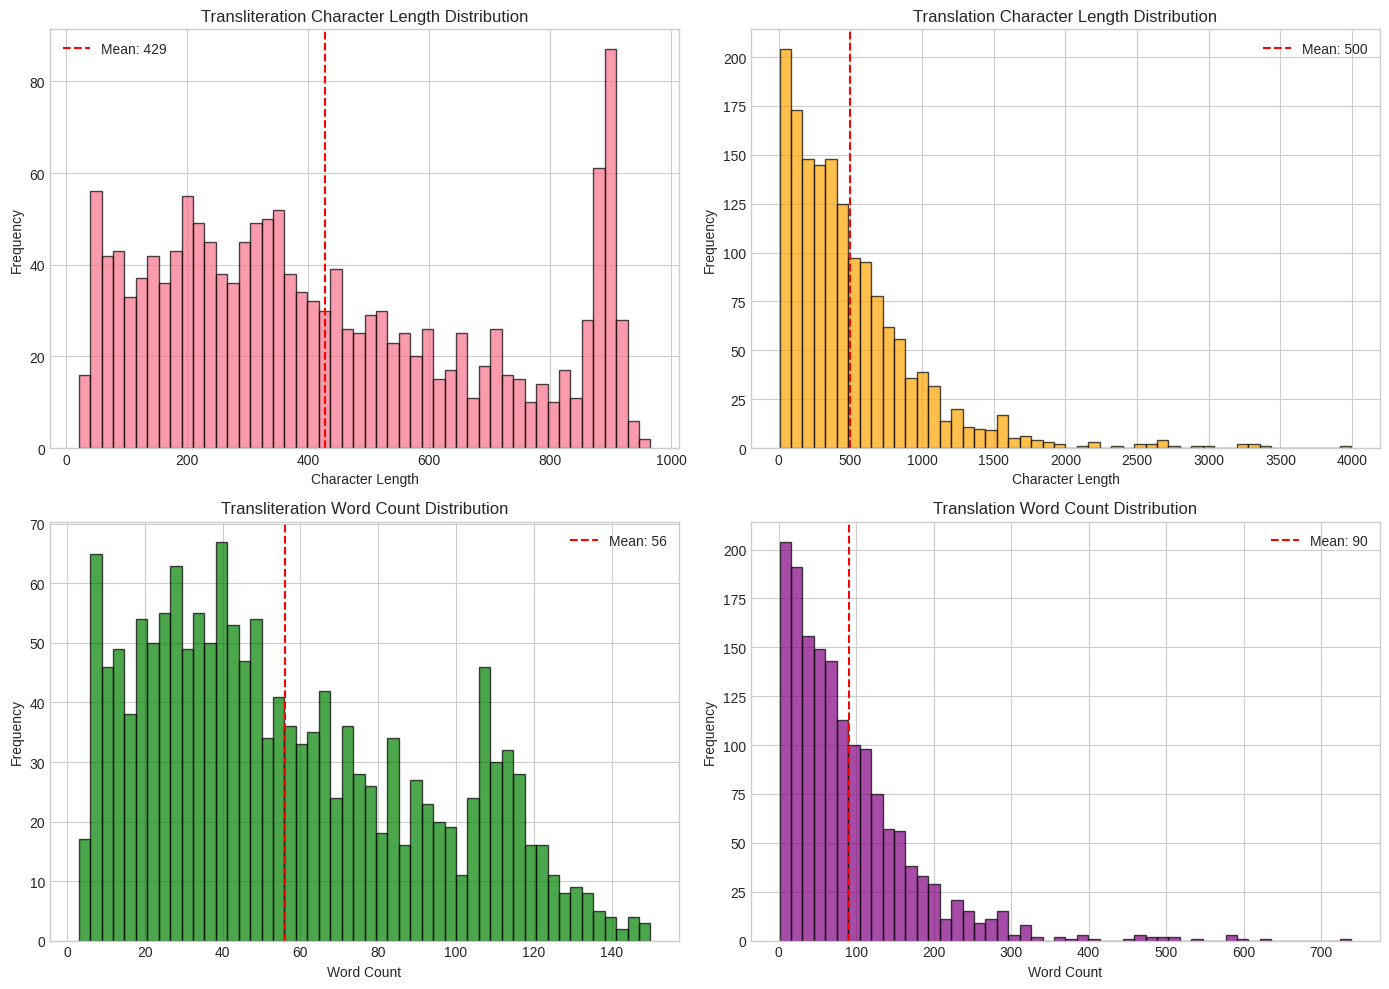

Figure saved to ../output/images/text_length_distributions.png


In [6]:
# Create visualization of text lengths
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Transliteration character length
axes[0, 0].hist(train_df['transliteration_len'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Character Length')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Transliteration Character Length Distribution')
axes[0, 0].axvline(train_df['transliteration_len'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['transliteration_len'].mean():.0f}")
axes[0, 0].legend()

# Translation character length
axes[0, 1].hist(train_df['translation_len'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Character Length')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Translation Character Length Distribution')
axes[0, 1].axvline(train_df['translation_len'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['translation_len'].mean():.0f}")
axes[0, 1].legend()

# Transliteration word count
axes[1, 0].hist(train_df['transliteration_words'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Transliteration Word Count Distribution')
axes[1, 0].axvline(train_df['transliteration_words'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['transliteration_words'].mean():.0f}")
axes[1, 0].legend()

# Translation word count
axes[1, 1].hist(train_df['translation_words'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Translation Word Count Distribution')
axes[1, 1].axvline(train_df['translation_words'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['translation_words'].mean():.0f}")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'text_length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {IMAGES_DIR / 'text_length_distributions.png'}")

## 2.3 Length Ratio Analysis

=== Length Ratio Statistics (Translation / Transliteration) ===
       length_ratio   word_ratio
count   1561.000000  1561.000000
mean       1.089983     1.487067
std        0.492851     0.675573
min        0.011472     0.014706
25%        0.981043     1.280000
50%        1.081050     1.483516
75%        1.184211     1.655172
max        9.245675    11.000000


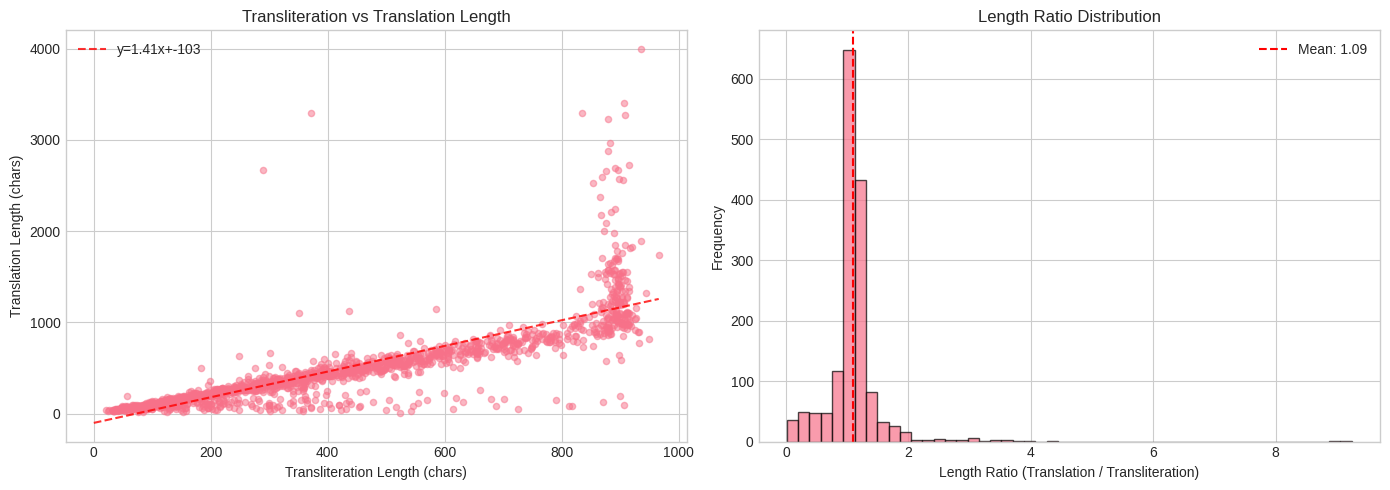

In [7]:
# Calculate length ratio (translation / transliteration)
train_df['length_ratio'] = train_df['translation_len'] / train_df['transliteration_len']
train_df['word_ratio'] = train_df['translation_words'] / train_df['transliteration_words']

print("=== Length Ratio Statistics (Translation / Transliteration) ===")
print(train_df[['length_ratio', 'word_ratio']].describe())

# Scatter plot of length ratios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train_df['transliteration_len'], train_df['translation_len'], alpha=0.5, s=20)
axes[0].set_xlabel('Transliteration Length (chars)')
axes[0].set_ylabel('Translation Length (chars)')
axes[0].set_title('Transliteration vs Translation Length')

# Add regression line
z = np.polyfit(train_df['transliteration_len'], train_df['translation_len'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, train_df['transliteration_len'].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", alpha=0.8, label=f'y={z[0]:.2f}x+{z[1]:.0f}')
axes[0].legend()

axes[1].hist(train_df['length_ratio'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Length Ratio (Translation / Transliteration)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Length Ratio Distribution')
axes[1].axvline(train_df['length_ratio'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['length_ratio'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'length_ratio_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4 Vocabulary Analysis

In [8]:
# Analyze vocabulary in transliterations
from collections import Counter

def tokenize_akkadian(text):
    """Tokenize Akkadian transliteration"""
    if pd.isna(text):
        return []
    # Split by whitespace and common delimiters
    tokens = re.findall(r'\b\w+\b|[{}<>.]', str(text))
    return tokens

# Tokenize all transliterations
all_tokens = []
for text in train_df['transliteration']:
    all_tokens.extend(tokenize_akkadian(text))

token_counts = Counter(all_tokens)

print(f"Total tokens: {len(all_tokens)}")
print(f"Unique tokens: {len(token_counts)}")
print(f"\nMost common tokens:")
for token, count in token_counts.most_common(30):
    print(f"  {token}: {count}")

Total tokens: 232442
Unique tokens: 561

Most common tokens:
  a: 20534
  ma: 13299
  na: 11084
  .: 7995
  ša: 6179
  i: 5998
  ni: 4884
  šu: 4674
  lá: 4495
  ú: 3671
  KÙ: 3620
  ku: 3458
  BABBAR: 3395
  um: 3395
  tí: 3309
  <: 3224
  gap: 3224
  >: 3224
  ta: 2909
  nu: 2831
  im: 2737
  kà: 2691
  dí: 2545
  li: 2377
  šur: 2063
  GÍN: 2047
  ba: 2032
  ki: 2017
  DUMU: 1937
  ù: 1899


In [9]:
# Analyze vocabulary in English translations
all_english_tokens = []
for text in train_df['translation']:
    if pd.notna(text):
        words = re.findall(r'\b[a-zA-Z]+\b', str(text).lower())
        all_english_tokens.extend(words)

english_token_counts = Counter(all_english_tokens)

print(f"Total English tokens: {len(all_english_tokens)}")
print(f"Unique English tokens: {len(english_token_counts)}")
print(f"\nMost common English words:")
for token, count in english_token_counts.most_common(30):
    print(f"  {token}: {count}")

Total English tokens: 132043
Unique English tokens: 3666

Most common English words:
  of: 8922
  the: 6991
  and: 4776
  to: 4348
  silver: 3646
  gap: 2483
  you: 2376
  i: 2105
  for: 2046
  son: 1966
  in: 1713
  shekels: 1624
  minas: 1540
  from: 1466
  my: 1451
  by: 1320
  he: 1272
  me: 1221
  with: 1179
  a: 1170
  that: 1104
  mina: 1055
  your: 1048
  it: 1025
  not: 1014
  is: 902
  will: 879
  have: 879
  as: 877
  ennam: 855


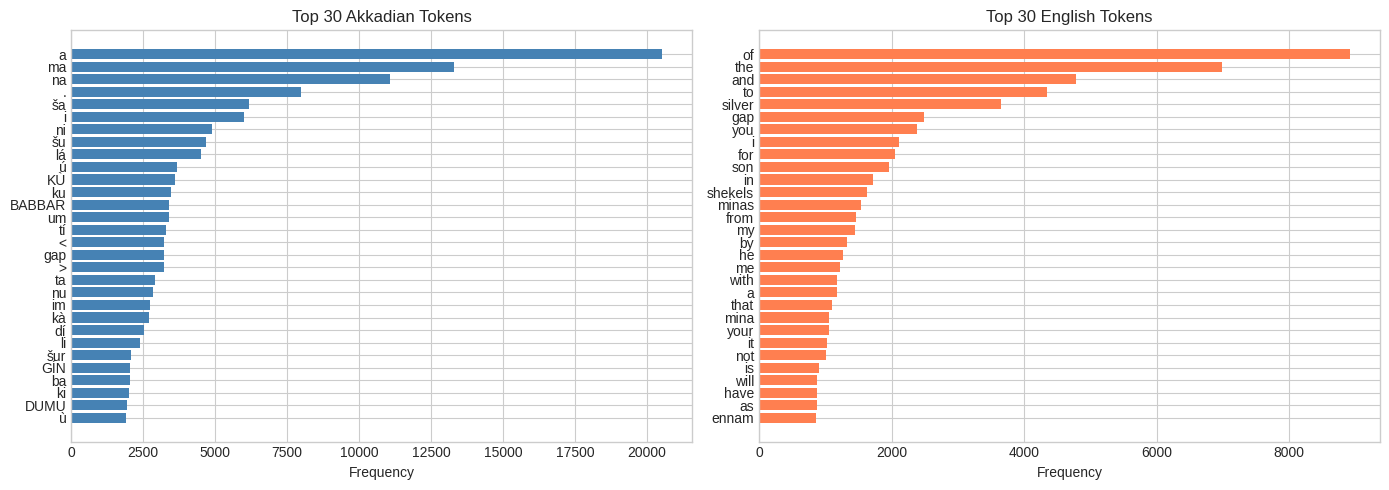

In [10]:
# Visualize vocabulary frequency
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 30 Akkadian tokens
top_akk_tokens = token_counts.most_common(30)
tokens, counts = zip(*top_akk_tokens)
axes[0].barh(range(len(tokens)), counts, color='steelblue')
axes[0].set_yticks(range(len(tokens)))
axes[0].set_yticklabels(tokens)
axes[0].invert_yaxis()
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 30 Akkadian Tokens')

# Top 30 English tokens
top_eng_tokens = english_token_counts.most_common(30)
tokens, counts = zip(*top_eng_tokens)
axes[1].barh(range(len(tokens)), counts, color='coral')
axes[1].set_yticks(range(len(tokens)))
axes[1].set_yticklabels(tokens)
axes[1].invert_yaxis()
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 30 English Tokens')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'vocabulary_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.5 Special Character Analysis

Akkadian transliterations contain special characters and notation that need to be handled.

In [11]:
# Analyze special characters and patterns in transliterations
def analyze_special_chars(text):
    """Count special characters in Akkadian transliteration"""
    if pd.isna(text):
        return {}
    text = str(text)
    return {
        'gaps': text.count('<gap>') + text.count('<big_gap>'),
        'determinatives': text.count('{'),  # curly brackets for determinatives
        'broken_brackets': text.count('[') + text.count(']'),
        'superscripts': len(re.findall(r'[₀-₉ₓ]', text)),
        'special_markers': text.count('!') + text.count('?') + text.count('/'),
    }

# Apply to all rows
special_chars_df = train_df['transliteration'].apply(analyze_special_chars).apply(pd.Series)
train_df = pd.concat([train_df, special_chars_df], axis=1)

print("=== Special Characters Statistics ===")
print(special_chars_df.describe())

=== Special Characters Statistics ===
              gaps  determinatives  broken_brackets  superscripts  \
count  1561.000000     1561.000000           1561.0   1561.000000   
mean      2.065343        0.554132              0.0      2.352338   
std       4.216066        0.985041              0.0      2.424794   
min       0.000000        0.000000              0.0      0.000000   
25%       0.000000        0.000000              0.0      1.000000   
50%       0.000000        0.000000              0.0      2.000000   
75%       2.000000        1.000000              0.0      3.000000   
max      40.000000        7.000000              0.0     18.000000   

       special_markers  
count           1561.0  
mean               0.0  
std                0.0  
min                0.0  
25%                0.0  
50%                0.0  
75%                0.0  
max                0.0  


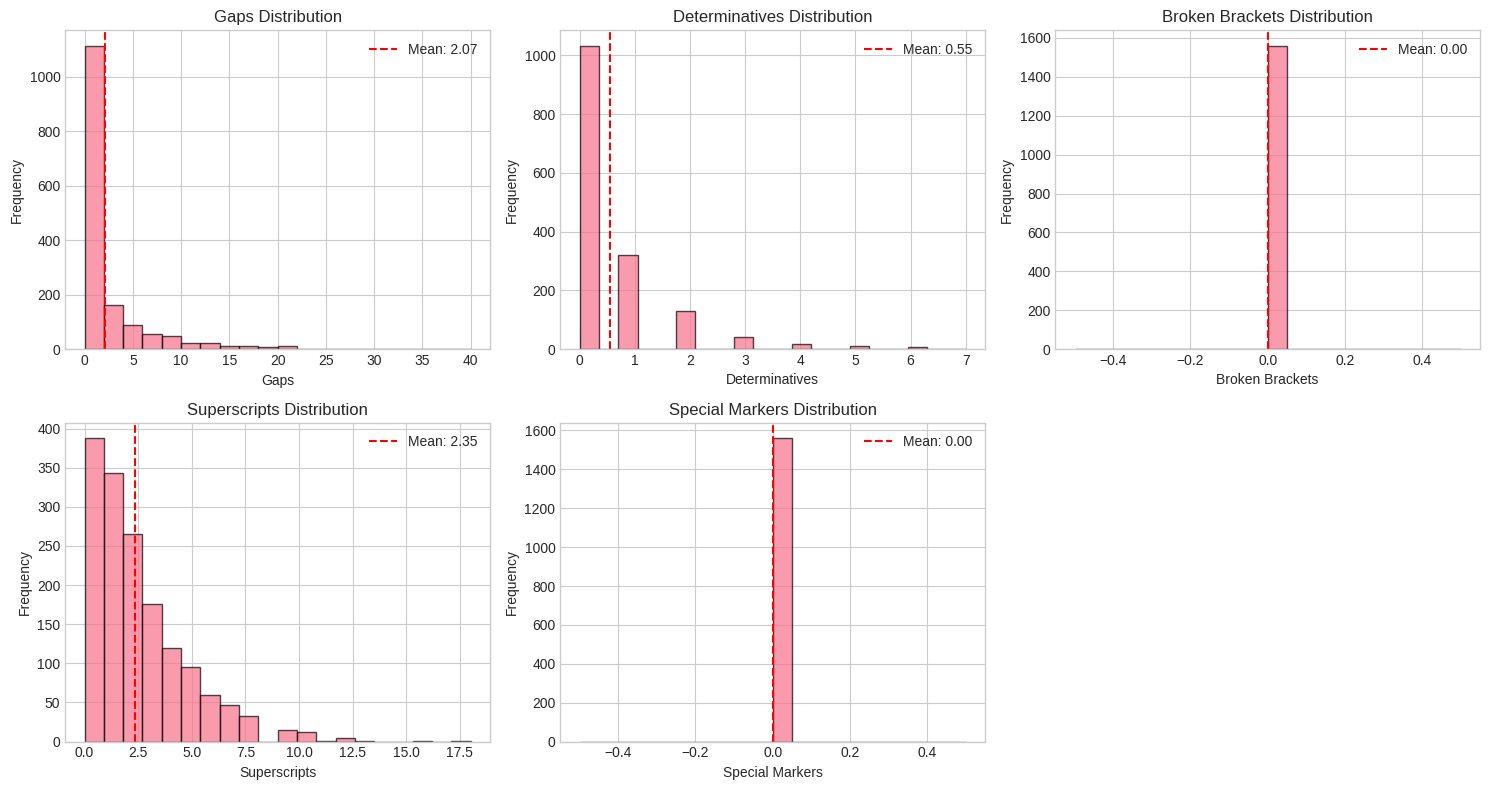

In [12]:
# Visualize special character distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, col in enumerate(['gaps', 'determinatives', 'broken_brackets', 'superscripts', 'special_markers']):
    ax = axes[idx // 3, idx % 3]
    data = train_df[col]
    ax.hist(data, bins=20, edgecolor='black', alpha=0.7)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.set_title(f'{col.replace("_", " ").title()} Distribution')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f"Mean: {data.mean():.2f}")
    ax.legend()

axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'special_characters_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.6 Analyze External Lexicon Data

In [13]:
# Load external lexicon data
lexicon_df = pd.read_csv(DATA_DIR / "OA_Lexicon_eBL.csv")
print(f"Lexicon shape: {lexicon_df.shape}")
print(f"\nColumns: {lexicon_df.columns.tolist()}")
print(f"\nWord types:")
print(lexicon_df['type'].value_counts())

Lexicon shape: (39332, 9)

Columns: ['type', 'form', 'norm', 'lexeme', 'eBL', 'I_IV', 'A_D', 'Female(f)', 'Alt_lex']

Word types:
type
word    25574
PN      13424
GN        334
Name: count, dtype: int64


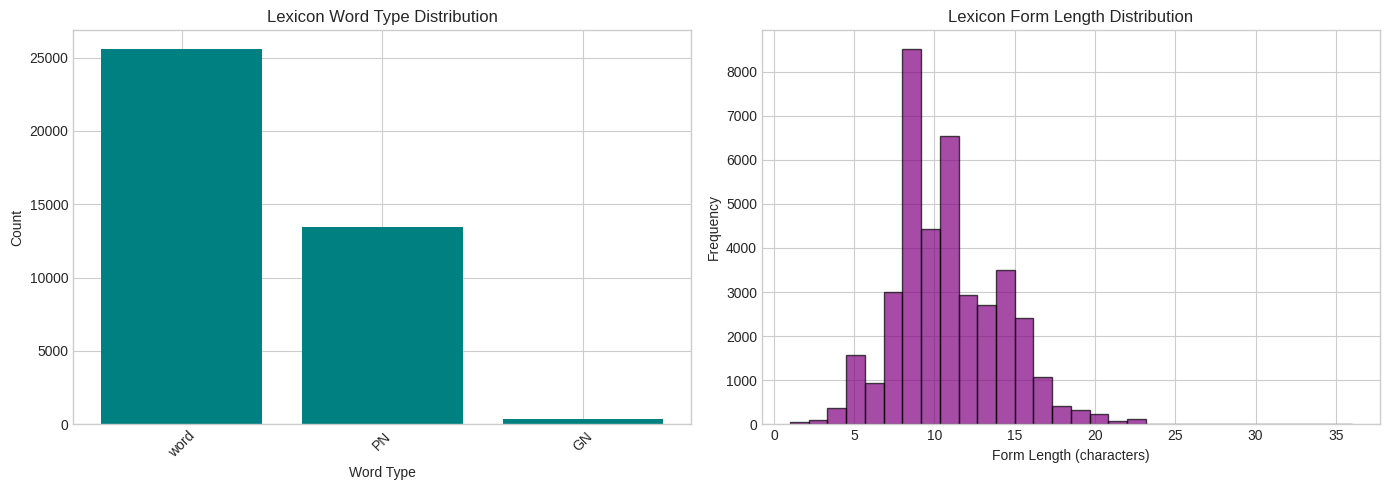

In [14]:
# Analyze word types
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word type distribution
word_type_counts = lexicon_df['type'].value_counts()
axes[0].bar(word_type_counts.index, word_type_counts.values, color='teal')
axes[0].set_xlabel('Word Type')
axes[0].set_ylabel('Count')
axes[0].set_title('Lexicon Word Type Distribution')
axes[0].tick_params(axis='x', rotation=45)

# Form length distribution
lexicon_df['form_len'] = lexicon_df['form'].str.len()
axes[1].hist(lexicon_df['form_len'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1].set_xlabel('Form Length (characters)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Lexicon Form Length Distribution')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'lexicon_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.7 Test Data Overview

In [15]:
# Load test data
test_df = pd.read_csv(DATA_DIR / "test.csv")
print(f"Test data shape: {test_df.shape}")
print(f"\nColumns: {test_df.columns.tolist()}")
print(f"\nSample entries:")
test_df.head()

Test data shape: (4, 5)

Columns: ['id', 'text_id', 'line_start', 'line_end', 'transliteration']

Sample entries:


,id,text_id,line_start,line_end,transliteration
0,0,332fda50,1,7,um-ma kà-ru-um kà-ni-ia-ma a-na aa-qí-il… da-t...
1,1,332fda50,7,14,i-na mup-pì-im aa a-lim(ki) ia-tù u„-mì-im a-n...
2,2,332fda50,14,24,ki-ma mup-pì-ni ta-áa-me-a-ni a-ma-kam lu a-na...
3,3,332fda50,25,30,me-+e-er mup-pì-ni a-na kà-ar kà-ar-ma ú wa-ba...


In [16]:
# Analyze test data
test_df['transliteration_len'] = test_df['transliteration'].str.len()
test_df['transliteration_words'] = test_df['transliteration'].str.split().str.len()

print("=== Test Data Statistics ===")
print(test_df[['transliteration_len', 'transliteration_words']].describe())

print(f"\nUnique text_ids: {test_df['text_id'].nunique()}")

=== Test Data Statistics ===
       transliteration_len  transliteration_words
count             4.000000               4.000000
mean            168.750000              21.250000
std              65.900809               8.616844
min             129.000000              16.000000
25%             132.000000              16.000000
50%             139.500000              17.500000
75%             176.250000              22.750000
max             267.000000              34.000000

Unique text_ids: 1


## 2.8 Compare Train vs Test Data

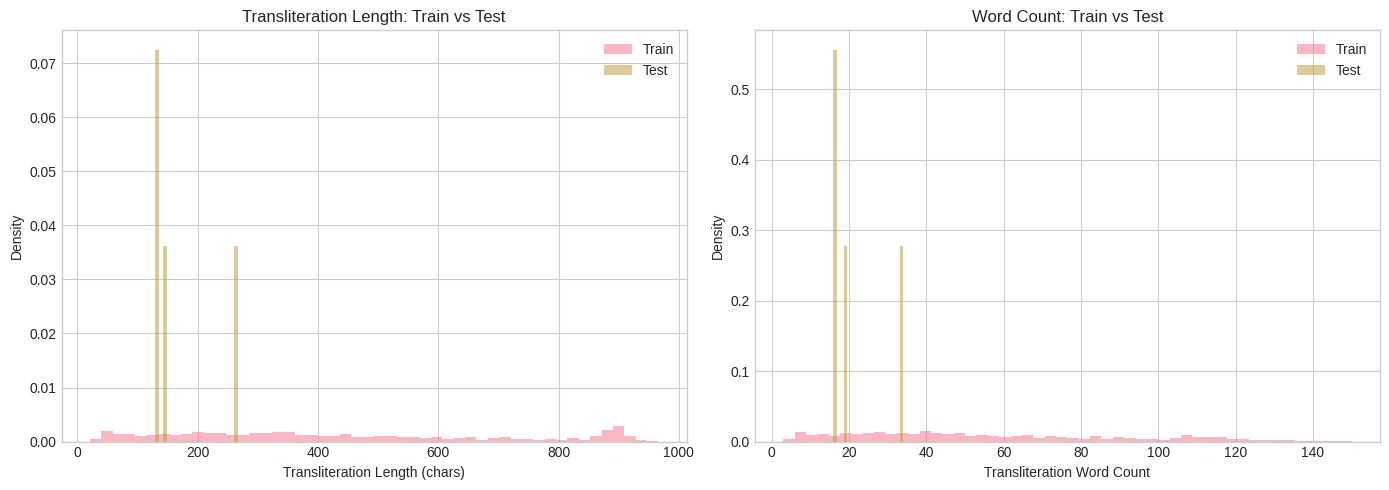

In [17]:
# Compare train and test data distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length comparison
axes[0].hist(train_df['transliteration_len'], bins=50, alpha=0.5, label='Train', density=True)
axes[0].hist(test_df['transliteration_len'], bins=20, alpha=0.5, label='Test', density=True)
axes[0].set_xlabel('Transliteration Length (chars)')
axes[0].set_ylabel('Density')
axes[0].set_title('Transliteration Length: Train vs Test')
axes[0].legend()

# Word count comparison
axes[1].hist(train_df['transliteration_words'], bins=50, alpha=0.5, label='Train', density=True)
axes[1].hist(test_df['transliteration_words'], bins=20, alpha=0.5, label='Test', density=True)
axes[1].set_xlabel('Transliteration Word Count')
axes[1].set_ylabel('Density')
axes[1].set_title('Word Count: Train vs Test')
axes[1].legend()

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'train_test_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.9 EDA Summary

In [18]:
# Create summary statistics
eda_summary = {
    "training_data": {
        "total_samples": len(train_df),
        "avg_transliteration_len": float(train_df['transliteration_len'].mean()),
        "avg_translation_len": float(train_df['translation_len'].mean()),
        "avg_transliteration_words": float(train_df['transliteration_words'].mean()),
        "avg_translation_words": float(train_df['translation_words'].mean()),
        "unique_akkadian_tokens": len(token_counts),
        "unique_english_tokens": len(english_token_counts),
        "avg_length_ratio": float(train_df['length_ratio'].mean()),
    },
    "test_data": {
        "total_samples": len(test_df),
        "unique_documents": int(test_df['text_id'].nunique()),
        "avg_transliteration_len": float(test_df['transliteration_len'].mean()),
    },
    "lexicon": {
        "total_entries": len(lexicon_df),
        "word_types": lexicon_df['type'].value_counts().to_dict()
    }
}

print("=== EDA Summary ===")
for key, value in eda_summary.items():
    print(f"\n{key.upper()}:")
    for k, v in value.items():
        if isinstance(v, dict):
            print(f"  {k}: {v}")
        else:
            print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")

=== EDA Summary ===

TRAINING_DATA:
  total_samples: 1561
  avg_transliteration_len: 428.82
  avg_translation_len: 500.42
  avg_transliteration_words: 56.16
  avg_translation_words: 89.99
  unique_akkadian_tokens: 561
  unique_english_tokens: 3666
  avg_length_ratio: 1.09

TEST_DATA:
  total_samples: 4
  unique_documents: 1
  avg_transliteration_len: 168.75

LEXICON:
  total_entries: 39332
  word_types: {'word': 25574, 'PN': 13424, 'GN': 334}


In [19]:
# Save summary
with open(OUTPUT_DIR / "eda_summary.json", 'w') as f:
    json.dump(eda_summary, f, indent=2)
print(f"EDA summary saved to {OUTPUT_DIR / 'eda_summary.json'}")

EDA summary saved to ../output/eda_summary.json


In [20]:
# Verify notebook is valid JSON
import json

notebook_path = Path("notebooks/02_exploratory_data_analysis.ipynb")
if notebook_path.exists():
    with open(notebook_path, 'r') as f:
        nb = json.load(f)
    print(f"Notebook is valid JSON with {len(nb['cells'])} cells")